# Linear Regression

**Dataset:** Advertising.csv — TV / Radio / Newspaper ad spend → Sales

**Flow:**
1. Intuition (bakery example)
2. Simple LR — one predictor (TV → Sales)
3. Multiple LR — all three predictors
4. Statsmodels — p-values, significance
5. Evaluation metrics — MAE, RMSE, MAPE, R²
6. Residual plots — check assumptions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import statsmodels.formula.api as sm

## 1. Intuition — Bakery Example

Simplest possible LR: how long does it take to bake N muffins?

```
Time = β₀ + β₁ × Muffins
```

β₁ = extra minutes per muffin, β₀ = fixed setup time.

   Muffins  Time Taken
0        1           5
1        2           8
2        4          12
3        3           6
4        2           4
5        5          14
6        7          18
7        4           7
8        2          10
9        6          13

Intercept (setup time): 2.60 mins
Coefficient (per muffin): 1.97 mins
Prediction for 5 muffins: 12.46 mins


/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


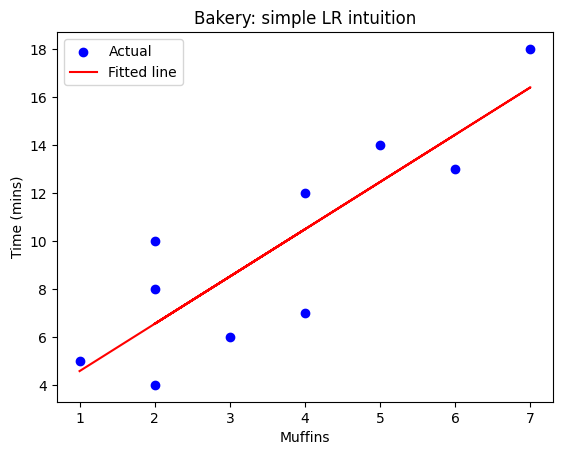

In [3]:
bakery = pd.read_csv('/home/navneet/projects/python/ML/Introduction-to-Linear-Regression-Material/Datasets and Notebooks/bakery_muffins.csv')
print(bakery)

X_b = bakery[['Muffins']]
y_b = bakery['Time Taken']

model_b = LinearRegression().fit(X_b, y_b)
print(f"\nIntercept (setup time): {model_b.intercept_:.2f} mins")
print(f"Coefficient (per muffin): {model_b.coef_[0]:.2f} mins")
print(f"Prediction for 5 muffins: {model_b.predict([[5]])[0]:.2f} mins")

plt.scatter(X_b, y_b, color='blue', label='Actual')
plt.plot(X_b, model_b.predict(X_b), color='red', label='Fitted line')
plt.xlabel('Muffins'); plt.ylabel('Time (mins)'); plt.legend()
plt.title('Bakery: simple LR intuition'); plt.show()

## 2. Load Advertising Dataset

In [4]:
df = pd.read_csv('/home/navneet/projects/python/ML/Introduction-to-Linear-Regression-Material/Datasets and Notebooks/Advertising.csv')
print(df.shape)
df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


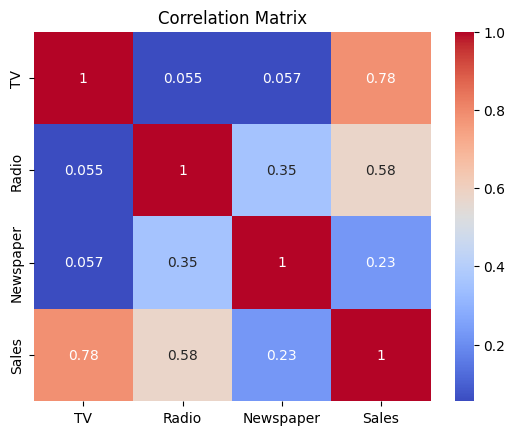

In [5]:
# Which channel correlates most with Sales?
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix'); plt.show()
# TV r≈0.78 (strongest), Radio r≈0.58, Newspaper r≈0.23 (weakest)

## 3. Simple Linear Regression — TV → Sales

In [7]:
X_slr = df[['TV']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X_slr, y, test_size=0.2, random_state=42)

slr = LinearRegression().fit(X_train, y_train)

print(f"Intercept β₀: {slr.intercept_:.4f}")
print(f"Coefficient β₁ (TV): {slr.coef_[0]:.4f}")
print(f"\nModel: Sales = {slr.intercept_:.4f} + {slr.coef_[0]:.4f} × TV")
print("Interpretation: each ₹1000 extra on TV → {:.4f} units more sales".format(slr.coef_[0]))

Intercept β₀: 7.1196
Coefficient β₁ (TV): 0.0465

Model: Sales = 7.1196 + 0.0465 × TV
Interpretation: each ₹1000 extra on TV → 0.0465 units more sales


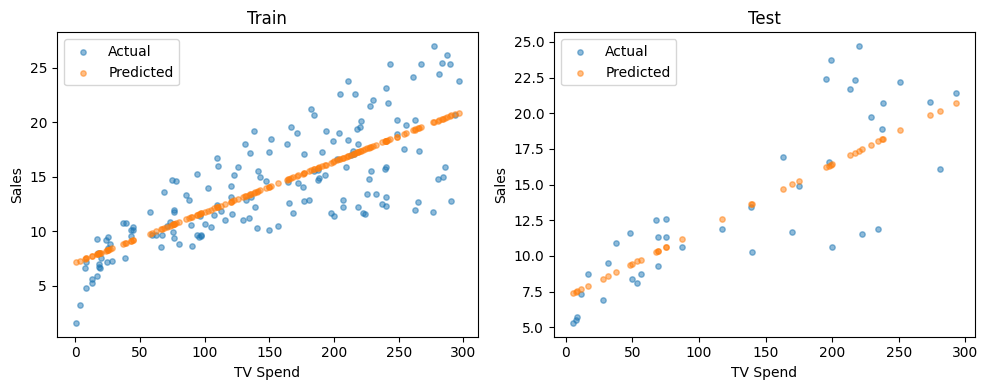

In [8]:
y_train_pred_slr = slr.predict(X_train)
y_test_pred_slr  = slr.predict(X_test)

plt.figure(figsize=(10, 4))
for i, (X_split, y_split, y_pred, title) in enumerate([
    (X_train, y_train, y_train_pred_slr, 'Train'),
    (X_test,  y_test,  y_test_pred_slr,  'Test')
], 1):
    plt.subplot(1, 2, i)
    plt.scatter(X_split['TV'], y_split, alpha=0.5, s=15, label='Actual')
    plt.scatter(X_split['TV'], y_pred,  alpha=0.5, s=15, label='Predicted')
    plt.xlabel('TV Spend'); plt.ylabel('Sales'); plt.title(title); plt.legend()
plt.tight_layout(); plt.show()

## 4. Evaluation Metrics Helper

| Metric | Good when | Thumb rule |
|--------|-----------|------------|
| MAE | Outliers present | MAE << mean of y |
| RMSE | Large errors are costly | RMSE < std dev of y |
| MAPE | Need % error | < 10% good, > 20% poor |
| R² | General fit | Closer to 1 is better |
| Adj R² | Comparing models with diff # features | Higher is better |

In [ ]:
def eval_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    n, p = len(y_true), 1  # override p below
    return {'Label': label, 'MAE': mae, 'RMSE': rmse, 'MAPE%': mape,
            'R²': r2, 'y_mean': y_true.mean(), 'y_std': y_true.std()}

pd.DataFrame([
    eval_metrics(y_train, y_train_pred_slr, 'Train SLR'),
    eval_metrics(y_test,  y_test_pred_slr,  'Test  SLR'),
]).set_index('Label').round(3)

## 5. Multiple Linear Regression — TV + Radio + Newspaper → Sales

Adding more predictors should explain more variance (R² should rise).

In [ ]:
X_mlr = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mlr, y, test_size=0.2, random_state=42)

mlr = LinearRegression().fit(X_train_m, y_train_m)

print(f"Intercept β₀: {mlr.intercept_:.4f}")
for feat, coef in zip(X_mlr.columns, mlr.coef_):
    print(f"  β ({feat:12}): {coef:.4f}")

In [ ]:
y_train_pred_m = mlr.predict(X_train_m)
y_test_pred_m  = mlr.predict(X_test_m)

# Compare SLR vs MLR
results = pd.DataFrame([
    eval_metrics(y_train,   y_train_pred_slr, 'Train SLR (TV only)'),
    eval_metrics(y_test,    y_test_pred_slr,  'Test  SLR (TV only)'),
    eval_metrics(y_train_m, y_train_pred_m,   'Train MLR (all 3)'),
    eval_metrics(y_test_m,  y_test_pred_m,    'Test  MLR (all 3)'),
]).set_index('Label').round(3)
results
# MLR R²≈0.90 vs SLR R²≈0.60 — big improvement from adding Radio

## 6. Statsmodels — Which Predictors Are Significant?

`P>|t|` column: if p < 0.05 → predictor is statistically significant at 95% confidence.

In [ ]:
train_df = X_train_m.copy()
train_df['Sales'] = y_train_m

sm_model = sm.ols('Sales ~ TV + Radio + Newspaper', data=train_df).fit()
print(sm_model.summary())
# Newspaper p=0.696 → NOT significant → can drop it
# TV and Radio both p < 0.001 → strongly significant

In [ ]:
# Drop Newspaper and re-run
sm_model2 = sm.ols('Sales ~ TV + Radio', data=train_df).fit()
print(sm_model2.summary())
# Adj R² stays ~same → Newspaper was adding noise, not signal

## 7. Residual Analysis — Check Assumptions

- **Residuals vs Fitted:** random scatter around 0 → homoscedastic (good); funnel shape → heteroscedastic (problem)
- **Histogram of residuals:** roughly normal → LR assumption holds

In [ ]:
residuals_train = y_train_m - y_train_pred_m
residuals_test  = y_test_m  - y_test_pred_m

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Residuals vs fitted
axes[0].scatter(y_train_pred_m, residuals_train, alpha=0.5, label='Train')
axes[0].scatter(y_test_pred_m,  residuals_test,  alpha=0.5, label='Test')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted — look for random scatter'); axes[0].legend()

# Histogram
sns.histplot(residuals_train, kde=True, ax=axes[1], color='blue',   alpha=0.5, label='Train')
sns.histplot(residuals_test,  kde=True, ax=axes[1], color='orange', alpha=0.5, label='Test')
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residual Distribution — should be ~normal'); axes[1].legend()

plt.tight_layout(); plt.show()
# Mild funnel → slight heteroscedasticity; not perfectly normal

## 8. Summary

| Model | R² (Test) | RMSE (Test) | Takeaway |
|-------|-----------|-------------|----------|
| SLR: TV only | ~0.60 | ~3.5 | One channel leaves 40% unexplained |
| MLR: TV+Radio+Newspaper | ~0.90 | ~1.8 | Much better |
| MLR: TV+Radio only | ~0.90 | ~1.8 | Newspaper adds nothing |

**Key learnings:**
- More relevant features → higher R²
- Use p-values (statsmodels) to drop insignificant predictors
- Always check residual plots — a funnel shape means your model is missing something
- RMSE of 1.8 vs y_std ≈ 5 → model beats naive mean by 3x

---

## 9. Bakery + Staff — MLR with 2 Predictors (Intuition)

Adding a second predictor (Staff) to the bakery example — shows how MLR works conceptually before scaling up.

`Time = β₀ + β₁ × Muffins + β₂ × Staff`

In [ ]:
bakery2 = pd.read_csv('/home/navneet/projects/python/ML/Introduction-to-Linear-Regression-Material/Datasets and Notebooks/bakery_muffins_with_staff.csv')
print(bakery2)

X_b2 = bakery2[['Muffins', 'Staff']]
y_b2 = bakery2['Time Taken']

model_b2 = LinearRegression().fit(X_b2, y_b2)
print(f"\nIntercept β₀: {model_b2.intercept_:.2f}")
for feat, coef in zip(X_b2.columns, model_b2.coef_):
    print(f"  β ({feat}): {coef:.2f}")

# Compare: same Muffins count, but with more Staff → faster?
print("\nPredictions:")
print(f"  3 muffins, 1 staff: {model_b2.predict([[3, 1]])[0]:.2f} mins")
print(f"  3 muffins, 2 staff: {model_b2.predict([[3, 2]])[0]:.2f} mins")
# Negative Staff coef = more staff → less time (makes sense)

---

## 10. College Dataset — Practice

777 US colleges. Predict **Apps** (number of applications received).

Features include: `Accept`, `Enroll`, `Top10perc`, `Outstate`, `Room.Board`, `PhD`, `Grad.Rate`, `Private` (categorical), etc.

In [ ]:
college = pd.read_excel('/home/navneet/projects/python/ML/Introduction-to-Linear-Regression-Material/Datasets and Notebooks/College.xlsx')
college = college.rename(columns={'Unnamed: 0': 'Name'}).set_index('Name')
print(college.shape)
college.head()

In [ ]:
college.describe()

In [ ]:
# Encode Private (Yes/No → 1/0)
college['Private'] = (college['Private'] == 'Yes').astype(int)

# Features and target
features = ['Accept', 'Enroll', 'Top10perc', 'Outstate', 'Room.Board', 'PhD', 'Grad.Rate', 'Private']
X_c = college[features]
y_c = college['Apps']

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

model_c = LinearRegression().fit(X_c_train, y_c_train)
y_c_pred = model_c.predict(X_c_test)

print("Coefficients:")
for feat, coef in zip(features, model_c.coef_):
    print(f"  {feat:15}: {coef:10.2f}")

print()
pd.DataFrame([eval_metrics(y_c_test, y_c_pred, 'College MLR')]).set_index('Label').round(2)

In [ ]:
# Statsmodels — check which features are significant
# Rename columns with dots (patsy formula parser can't handle them)
train_c = X_c_train.copy()
train_c.columns = [c.replace('.', '_') for c in train_c.columns]
train_c['Apps'] = y_c_train

clean_features = [f.replace('.', '_') for f in features]
formula = 'Apps ~ ' + ' + '.join(clean_features)

sm_college = sm.ols(formula, data=train_c).fit()
print(sm_college.summary())

# Significant predictors — skip intercept row
sig = sm_college.pvalues.iloc[1:][sm_college.pvalues.iloc[1:] < 0.05]
print("\nSignificant predictors (p < 0.05):")
print(sig.round(4))